# Vision-Based Traffic Flow Prediction Using YOLOv8 and LSTM
## Notebook 12: Multi-Horizon & Error-Accumulation Analysis (Phase 12)

### Phase 12 Objective & Scientific Scope
In Phases 8 through 11, we established baseline benchmarks, developed compact recurrent neural networks (LSTM and GRU), and executed a four-way feature ablation study ($L = 10 	o H = 5$).

In **Phase 12**, we conduct a dedicated, systematic inquiry into **multi-horizon error progression**:
> **“How does forecasting error evolve across horizons $H = 1 \dots 5$ in direct multi-step traffic flow prediction, and does error accumulate monotonically as the lookahead distance increases?”**

### Strict Methodological Guardrails:
1. **Sampled-Observation Horizon Definition**:
   - The forecast steps $H_1, H_2, H_3, H_4, H_5$ correspond strictly to **discrete sampled surveillance clip observations**, **NOT fixed-minute physical clock intervals**.
   - Each horizon step $H_h$ represents prediction of traffic volume for the $h$-th future video clip.
2. **Direct Multi-Horizon Architecture Paradigm**:
   - All deep learning models evaluated (`CompactTrafficLSTM`, `CompactTrafficGRU`, Ablation Configs A–D) utilize **direct multi-step projection**: a single dense layer maps terminal recurrent hidden representations directly to all $5$ output horizons simultaneously.
   - We do **NOT** introduce recursive autoregressive rollouts (which would require unavailable future values of exogenous features such as HVR and occupancy).
   - In direct forecasting, errors at step $t+h$ are not mathematically constrained to compound, because output units are parameterized independently and optimized under a joint objective.
3. **Preservation of Existing Checkpoints & Frozen Preprocessing**:
   - We evaluate the exact frozen weights saved in `models/` without retraining or hyperparameter tuning.
   - Ground truth targets and lookback tensors are extracted strictly from `outputs/tables/traffic_timeseries.csv` using the established Phase 7 partition and frozen training-scaler parameters.
4. **Critical Small-Sample Limitation ($M_{\text{val}} = 3, M_{\text{test}} = 2$)**:
   - Consistent with Phases 7–11, non-overlapping target windowing on $N = 44$ discrete observations yields only $3$ validation windows and $2$ test windows.
   - We do **NOT** claim statistical significance or universal error accumulation laws; findings represent empirical properties of the evaluated test trajectories.
5. **Multi-Model Coverage**:
   - Deep Learning Models: Compact LSTM (Phase 9), Compact GRU (Phase 10), Feature Ablation Configs A–D (Phase 11).
   - Statistical Baselines: Persistence (Naïve), Moving Average (SMA-3), Moving Average (SMA-5).
6. **Required Deliverables**:
   - `outputs/tables/horizon_error_metrics.csv`
   - `outputs/figures/horizon_mae_curve.png`
   - `outputs/figures/horizon_rmse_curve.png`


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# Presentation styling
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Path setup
PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
INPUT_CSV_PATH = os.path.join(PROJECT_ROOT, "outputs", "tables", "traffic_timeseries.csv")
OUTPUT_TAB_DIR = os.path.join(PROJECT_ROOT, "outputs", "tables")
OUTPUT_FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
HORIZON_METRICS_PATH = os.path.join(OUTPUT_TAB_DIR, "horizon_error_metrics.csv")

os.makedirs(OUTPUT_TAB_DIR, exist_ok=True)
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Project root            : {PROJECT_ROOT}")
print(f"PyTorch version         : {torch.__version__}")
print(f"Input time-series path  : {INPUT_CSV_PATH}")
print(f"Horizon metrics export  : {HORIZON_METRICS_PATH}")


Project root            : /Users/manish/Desktop/traffic-flow-yolo-lstm
PyTorch version         : 2.13.0
Input time-series path  : /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/traffic_timeseries.csv
Horizon metrics export  : /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/horizon_error_metrics.csv


## 1. Ingestion & Ground Truth Partition Realignment

We load `outputs/tables/traffic_timeseries.csv` ($N = 44$) and verify the frozen partition bounds:
- **Train Split (70%)**: $n_{\text{train}} = 31$ observations ($k = 1 \dots 31$)
- **Validation Split (15%)**: $n_{\text{val}} = 7$ observations ($k = 32 \dots 38$)
- **Test Split (15%)**: $n_{\text{test}} = 6$ observations ($k = 39 \dots 44$)

We fit the target scaler `scaler_y` strictly on the training partition ($n_{\text{train}} = 31$) to obtain the exact normalization parameters ($\mu_{\text{train}}, \sigma_{\text{train}}$) used in Phases 9–11.


In [2]:
df = pd.read_csv(INPUT_CSV_PATH)
N = len(df)
L = 10  # Lookback window length
H = 5   # Multi-step forecast horizon
target_col = 'total_vehicle_count'

# Partition boundaries
n_train = int(round(N * 0.70))
n_val = int(round(N * 0.15))
n_test = N - n_train - n_val

train_df = df.iloc[:n_train].copy().reset_index(drop=True)
val_df = df.iloc[n_train:n_train + n_val].copy().reset_index(drop=True)
test_df = df.iloc[n_train + n_val:].copy().reset_index(drop=True)

# Frozen Target Scaler (Fitted strictly on Train)
scaler_y = StandardScaler()
scaler_y.fit(train_df[[target_col]].values)
mu_train = scaler_y.mean_[0]
sigma_train = scaler_y.scale_[0]

print(f"Dataset Size : N = {N} discrete observations")
print(f"Train Split  : {len(train_df)} observations (k={train_df['observation_index'].min()}..{train_df['observation_index'].max()})")
print(f"Val Split    : {len(val_df)} observations (k={val_df['observation_index'].min()}..{val_df['observation_index'].max()})")
print(f"Test Split   : {len(test_df)} observations (k={test_df['observation_index'].min()}..{test_df['observation_index'].max()})")
print(f"\nFrozen Train Scaler Parameters:")
print(f"  Target feature : {target_col}")
print(f"  Mean (mu)      : {mu_train:.4f} veh/frame")
print(f"  Std  (sigma)   : {sigma_train:.4f} veh/frame")

# Target-anchored sequence generation
train_set = set(range(0, n_train))
val_set = set(range(n_train, n_train + n_val))
test_set = set(range(n_train + n_val, N))

raw_windows = []
for t in range(L - 1, N - H):
    target_idx = list(range(t + 1, t + H + 1))
    lookback_idx = list(range(t - L + 1, t + 1))
    y_raw = df.loc[target_idx, target_col].values
    item = {
        'origin_t': t,
        'origin_k': t + 1,
        'lookback_idx': lookback_idx,
        'target_idx': target_idx,
        'y_raw': y_raw,
        'lookback_k': f"{lookback_idx[0]+1}..{lookback_idx[-1]+1}",
        'target_k': f"{target_idx[0]+1}..{target_idx[-1]+1}"
    }
    if all(idx in train_set for idx in target_idx):
        item['split'] = 'train'
    elif all(idx in val_set for idx in target_idx):
        item['split'] = 'val'
    elif all(idx in test_set for idx in target_idx):
        item['split'] = 'test'
    else:
        item['split'] = 'cross_boundary'
    raw_windows.append(item)

val_windows = [w for w in raw_windows if w['split'] == 'val']
test_windows = [w for w in raw_windows if w['split'] == 'test']

y_val_orig = np.array([w['y_raw'] for w in val_windows])
y_test_orig = np.array([w['y_raw'] for w in test_windows])

print(f"\nUsable Validation Windows (M_val) : {len(val_windows)} (Ground truth shape: {y_val_orig.shape})")
print(f"Usable Test Windows       (M_test): {len(test_windows)} (Ground truth shape: {y_test_orig.shape})")
print(f"CAVEAT: Small sample sizes (M_val=3, M_test=2) require non-generalizing statistical care.")


Dataset Size : N = 44 discrete observations
Train Split  : 31 observations (k=1..31)
Val Split    : 7 observations (k=32..38)
Test Split   : 6 observations (k=39..44)

Frozen Train Scaler Parameters:
  Target feature : total_vehicle_count
  Mean (mu)      : 8.7512 veh/frame
  Std  (sigma)   : 4.5703 veh/frame

Usable Validation Windows (M_val) : 3 (Ground truth shape: (3, 5))
Usable Test Windows       (M_test): 2 (Ground truth shape: (2, 5))
CAVEAT: Small sample sizes (M_val=3, M_test=2) require non-generalizing statistical care.


## 2. Direct Multi-Horizon Architecture Zoo & Out-of-Sample Prediction

We instantiate the model zoo using the exact checkpoint weights and formulations from prior phases:
- **CompactTrafficLSTM** (Phase 9 & Phase 11 Config A): 16 units, single layer, linear head $	o 5$ horizons.
- **CompactTrafficGRU** (Phase 10): 16 units, single layer, linear head $	o 5$ horizons.
- **Feature Ablation Models** (Phase 11):
  - Config B (Total Count + HVR, $D=2$)
  - Config C (Total Count + Occupancy, $D=2$)
  - Config D (Total Count + HVR + Occupancy, $D=3$)
- **Statistical Baselines** (Phase 8):
  - Persistence: $\hat{y}_{t+h} = y_t$
  - SMA-3: $\hat{y}_{t+h} = rac{1}{3} \sum_{i=0}^2 y_{t-i}$
  - SMA-5: $\hat{y}_{t+h} = rac{1}{5} \sum_{i=0}^4 y_{t-i}$

All model predictions are inverse-transformed to physical units (vehicles / frame) using the frozen scaler parameters:
$$\hat{y}_{\text{orig}} = \hat{y}_{\text{scaled}} \cdot \sigma_{\text{train}} + \mu_{\text{train}}$$


In [3]:
class CompactTrafficLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=16, num_layers=1, output_dim=5, dropout=0.10):
        super(CompactTrafficLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :]))

class CompactTrafficGRU(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=16, num_layers=1, output_dim=5, dropout=0.10):
        super(CompactTrafficGRU, self).__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, hn = self.gru(x)
        return self.fc(self.dropout(out[:, -1, :]))

# Specification of all evaluated models
EVAL_MODELS = {
    'Compact LSTM (Phase 9)': {
        'class': CompactTrafficLSTM,
        'input_dim': 1,
        'features': ['total_vehicle_count'],
        'ckpt': os.path.join(MODELS_DIR, 'lstm_best_model.pt'),
        'category': 'Recurrent Neural Network'
    },
    'Compact GRU (Phase 10)': {
        'class': CompactTrafficGRU,
        'input_dim': 1,
        'features': ['total_vehicle_count'],
        'ckpt': os.path.join(MODELS_DIR, 'gru_best_model.pt'),
        'category': 'Recurrent Neural Network'
    },
    'Config A (Total Count)': {
        'class': CompactTrafficLSTM,
        'input_dim': 1,
        'features': ['total_vehicle_count'],
        'ckpt': os.path.join(MODELS_DIR, 'ablation_config_a.pt'),
        'category': 'Feature Ablation'
    },
    'Config B (Total Count + HVR)': {
        'class': CompactTrafficLSTM,
        'input_dim': 2,
        'features': ['total_vehicle_count', 'HVR'],
        'ckpt': os.path.join(MODELS_DIR, 'ablation_config_b.pt'),
        'category': 'Feature Ablation'
    },
    'Config C (Total Count + Occupancy)': {
        'class': CompactTrafficLSTM,
        'input_dim': 2,
        'features': ['total_vehicle_count', 'occupancy_ratio'],
        'ckpt': os.path.join(MODELS_DIR, 'ablation_config_c.pt'),
        'category': 'Feature Ablation'
    },
    'Config D (Total Count + HVR + Occupancy)': {
        'class': CompactTrafficLSTM,
        'input_dim': 3,
        'features': ['total_vehicle_count', 'HVR', 'occupancy_ratio'],
        'ckpt': os.path.join(MODELS_DIR, 'ablation_config_d.pt'),
        'category': 'Feature Ablation'
    }
}

predictions_dict = {}

# Evaluate PyTorch checkpoints
for model_name, info in EVAL_MODELS.items():
    sc_x = StandardScaler()
    sc_x.fit(train_df[info['features']].values)
    
    X_val_list = [sc_x.transform(df.loc[w['lookback_idx'], info['features']].values) for w in val_windows]
    X_test_list = [sc_x.transform(df.loc[w['lookback_idx'], info['features']].values) for w in test_windows]
    
    X_val = torch.tensor(np.array(X_val_list), dtype=torch.float32)
    X_test = torch.tensor(np.array(X_test_list), dtype=torch.float32)
    
    m = info['class'](input_dim=info['input_dim'])
    m.load_state_dict(torch.load(info['ckpt'], map_location='cpu'))
    m.eval()
    
    with torch.no_grad():
        vp = m(X_val).numpy() * sigma_train + mu_train
        tp = m(X_test).numpy() * sigma_train + mu_train
        
    predictions_dict[model_name] = {
        'val_pred': vp,
        'test_pred': tp,
        'category': info['category']
    }
    print(f"Loaded checkpoint for: {model_name} (Val pred shape: {vp.shape}, Test pred shape: {tp.shape})")

# Evaluate Statistical Baselines
STAT_BASELINES = {
    'Persistence (Naïve)': lambda lk: np.repeat(lk[-1], H),
    'Moving Average (SMA K=3)': lambda lk: np.repeat(np.mean(lk[-3:]), H),
    'Moving Average (SMA K=5)': lambda lk: np.repeat(np.mean(lk[-5:]), H)
}

for b_name, b_func in STAT_BASELINES.items():
    vp = np.array([b_func(df.loc[w['lookback_idx'], target_col].values) for w in val_windows])
    tp = np.array([b_func(df.loc[w['lookback_idx'], target_col].values) for w in test_windows])
    predictions_dict[b_name] = {
        'val_pred': vp,
        'test_pred': tp,
        'category': 'Statistical Baseline'
    }
    print(f"Computed baseline for  : {b_name} (Val pred shape: {vp.shape}, Test pred shape: {tp.shape})")


Loaded checkpoint for: Compact LSTM (Phase 9) (Val pred shape: (3, 5), Test pred shape: (2, 5))
Loaded checkpoint for: Compact GRU (Phase 10) (Val pred shape: (3, 5), Test pred shape: (2, 5))
Loaded checkpoint for: Config A (Total Count) (Val pred shape: (3, 5), Test pred shape: (2, 5))
Loaded checkpoint for: Config B (Total Count + HVR) (Val pred shape: (3, 5), Test pred shape: (2, 5))
Loaded checkpoint for: Config C (Total Count + Occupancy) (Val pred shape: (3, 5), Test pred shape: (2, 5))
Loaded checkpoint for: Config D (Total Count + HVR + Occupancy) (Val pred shape: (3, 5), Test pred shape: (2, 5))
Computed baseline for  : Persistence (Naïve) (Val pred shape: (3, 5), Test pred shape: (2, 5))
Computed baseline for  : Moving Average (SMA K=3) (Val pred shape: (3, 5), Test pred shape: (2, 5))
Computed baseline for  : Moving Average (SMA K=5) (Val pred shape: (3, 5), Test pred shape: (2, 5))


## 3. Horizon-Wise Error Metrics ($H_1 \dots H_5$) & Drift Quantification

For each model and split, we evaluate:
1. **Horizon-Specific MAE and RMSE**:
   $$\text{MAE}(H_h) = \frac{1}{M} \sum_{m=1}^M |y_{m, h} - \hat{y}_{m, h}|, \quad \text{RMSE}(H_h) = \sqrt{\frac{1}{M} \sum_{m=1}^M (y_{m, h} - \hat{y}_{m, h})^2}$$
2. **Horizon Drift Quantification ($H_1 	o H_5$)**:
   $$\Delta_{\text{MAE}} = \text{MAE}(H_5) - \text{MAE}(H_1), \quad \% \Delta_{\text{MAE}} = \frac{\text{MAE}(H_5) - \text{MAE}(H_1)}{\text{MAE}(H_1)} \times 100\%$$
   $$\Delta_{\text{RMSE}} = \text{RMSE}(H_5) - \text{RMSE}(H_1), \quad \% \Delta_{\text{RMSE}} = \frac{\text{RMSE}(H_5) - \text{RMSE}(H_1)}{\text{RMSE}(H_1)} \times 100\%$$

We consolidate all records and export them to `outputs/tables/horizon_error_metrics.csv`.


In [4]:
records = []

for model_name, p_data in predictions_dict.items():
    for split_name, y_true, y_pred in [('Validation', y_val_orig, p_data['val_pred']),
                                       ('Test', y_test_orig, p_data['test_pred'])]:
        
        mae_h = np.mean(np.abs(y_true - y_pred), axis=0)
        rmse_h = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
        
        mae_overall = np.mean(np.abs(y_true - y_pred))
        rmse_overall = np.sqrt(np.mean((y_true - y_pred) ** 2))
        
        mae_delta = mae_h[-1] - mae_h[0]
        mae_pct = (mae_h[-1] - mae_h[0]) / mae_h[0] * 100.0
        
        rmse_delta = rmse_h[-1] - rmse_h[0]
        rmse_pct = (rmse_h[-1] - rmse_h[0]) / rmse_h[0] * 100.0
        
        rec = {
            'Split': split_name,
            'Model': model_name,
            'Category': p_data['category'],
            'Windows': len(y_true),
            'Overall_MAE': mae_overall,
            'Overall_RMSE': rmse_overall,
            'H1_MAE': mae_h[0],
            'H2_MAE': mae_h[1],
            'H3_MAE': mae_h[2],
            'H4_MAE': mae_h[3],
            'H5_MAE': mae_h[4],
            'H1_RMSE': rmse_h[0],
            'H2_RMSE': rmse_h[1],
            'H3_RMSE': rmse_h[2],
            'H4_RMSE': rmse_h[3],
            'H5_RMSE': rmse_h[4],
            'MAE_Delta_H1_to_H5': mae_delta,
            'MAE_Pct_Change_H1_to_H5': mae_pct,
            'RMSE_Delta_H1_to_H5': rmse_delta,
            'RMSE_Pct_Change_H1_to_H5': rmse_pct
        }
        records.append(rec)

df_horizon_metrics = pd.DataFrame(records)

# Export to CSV
df_horizon_metrics.to_csv(HORIZON_METRICS_PATH, index=False)
print(f"Exported complete multi-horizon error metrics to: {HORIZON_METRICS_PATH}")
print(f"Total evaluated model-split pairs: {len(df_horizon_metrics)}")


Exported complete multi-horizon error metrics to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/horizon_error_metrics.csv
Total evaluated model-split pairs: 18


## 4. Compact Horizon Error Comparison Tables

We examine the horizon-wise error progression separately for Validation and Test splits.


In [5]:
# Validation Split Table
val_view = df_horizon_metrics[df_horizon_metrics['Split'] == 'Validation'].copy()
print("=== VALIDATION SPLIT: HORIZON-WISE ERROR PROGRESSION (M_val = 3 windows) ===")
display(val_view[['Model', 'Category', 'H1_MAE', 'H2_MAE', 'H3_MAE', 'H4_MAE', 'H5_MAE',
                  'Overall_MAE', 'MAE_Delta_H1_to_H5', 'MAE_Pct_Change_H1_to_H5']].round(4))

# Test Split Table
test_view = df_horizon_metrics[df_horizon_metrics['Split'] == 'Test'].copy()
print("\n=== TEST SPLIT: HORIZON-WISE ERROR PROGRESSION (M_test = 2 windows) ===")
display(test_view[['Model', 'Category', 'H1_MAE', 'H2_MAE', 'H3_MAE', 'H4_MAE', 'H5_MAE',
                   'Overall_MAE', 'MAE_Delta_H1_to_H5', 'MAE_Pct_Change_H1_to_H5']].round(4))

# RMSE View for Test Split
print("\n=== TEST SPLIT: HORIZON-WISE RMSE PROGRESSION ===")
display(test_view[['Model', 'Category', 'H1_RMSE', 'H2_RMSE', 'H3_RMSE', 'H4_RMSE', 'H5_RMSE',
                   'Overall_RMSE', 'RMSE_Delta_H1_to_H5', 'RMSE_Pct_Change_H1_to_H5']].round(4))


=== VALIDATION SPLIT: HORIZON-WISE ERROR PROGRESSION (M_val = 3 windows) ===


,Model,Category,H1_MAE,H2_MAE,H3_MAE,H4_MAE,H5_MAE,Overall_MAE,MAE_Delta_H1_to_H5,MAE_Pct_Change_H1_to_H5
0,Compact LSTM (Phase 9),Recurrent Neural Network,0.8990,0.2810,0.6100,0.3900,0.6349,0.5630,-0.2642,-29.3823
2,Compact GRU (Phase 10),Recurrent Neural Network,0.4974,0.9957,0.0811,0.2056,1.1700,0.5899,0.6726,135.2350
4,Config A (Total Count),Feature Ablation,0.8990,0.2810,0.6100,0.3900,0.6349,0.5630,-0.2642,-29.3823
6,Config B (Total Count + HVR),Feature Ablation,0.6794,0.5300,0.4037,0.2255,1.5657,0.6809,0.8863,130.4528
8,Config C (Total Count + Occupancy),Feature Ablation,1.3510,0.3787,0.8014,0.2879,0.6950,0.7028,-0.6560,-48.5536
10,Config D (Total Count + HVR + Occupancy),Feature Ablation,0.6610,0.3691,0.4098,0.7553,0.9153,0.6221,0.2543,38.4648
12,Persistence (Naïve),Statistical Baseline,1.0843,0.4940,0.6697,0.3313,1.1920,0.7543,0.1077,9.9293
14,Moving Average (SMA K=3),Statistical Baseline,0.5306,0.4442,0.2992,0.4400,0.8682,0.5164,0.3377,63.6440
16,Moving Average (SMA K=5),Statistical Baseline,0.6533,0.9230,0.6833,0.9270,1.1213,0.8616,0.4679,71.6224



=== TEST SPLIT: HORIZON-WISE ERROR PROGRESSION (M_test = 2 windows) ===


,Model,Category,H1_MAE,H2_MAE,H3_MAE,H4_MAE,H5_MAE,Overall_MAE,MAE_Delta_H1_to_H5,MAE_Pct_Change_H1_to_H5
1,Compact LSTM (Phase 9),Recurrent Neural Network,0.8994,0.6406,0.9209,1.4480,1.1813,1.0181,0.2819,31.3463
3,Compact GRU (Phase 10),Recurrent Neural Network,0.2706,0.3330,0.5260,1.0944,1.6977,0.7843,1.4271,527.4257
5,Config A (Total Count),Feature Ablation,0.8994,0.6406,0.9209,1.4480,1.1813,1.0181,0.2819,31.3463
7,Config B (Total Count + HVR),Feature Ablation,0.6908,0.3349,0.4823,1.0982,2.1378,0.9488,1.4470,209.4613
9,Config C (Total Count + Occupancy),Feature Ablation,1.4064,0.9678,1.0780,1.1903,1.1400,1.1565,-0.2665,-18.9458
11,Config D (Total Count + HVR + Occupancy),Feature Ablation,0.6974,0.4048,0.7299,1.8226,1.4468,1.0203,0.7494,107.4589
13,Persistence (Naïve),Statistical Baseline,0.9215,1.0115,0.1565,1.7540,0.4580,0.8603,-0.4635,-50.2984
15,Moving Average (SMA K=3),Statistical Baseline,0.2712,0.3858,0.4968,1.1037,1.1083,0.6732,0.8372,308.7277
17,Moving Average (SMA K=5),Statistical Baseline,0.2599,0.4499,0.5081,1.0924,1.1196,0.6860,0.8597,330.7811



=== TEST SPLIT: HORIZON-WISE RMSE PROGRESSION ===


,Model,Category,H1_RMSE,H2_RMSE,H3_RMSE,H4_RMSE,H5_RMSE,Overall_RMSE,RMSE_Delta_H1_to_H5,RMSE_Pct_Change_H1_to_H5
1,Compact LSTM (Phase 9),Recurrent Neural Network,0.9135,0.7062,1.0611,1.8071,1.4823,1.2587,0.5688,62.2654
3,Compact GRU (Phase 10),Recurrent Neural Network,0.3770,0.4165,0.5800,1.4358,2.0363,1.1713,1.6593,440.1532
5,Config A (Total Count),Feature Ablation,0.9135,0.7062,1.0611,1.8071,1.4823,1.2587,0.5688,62.2654
7,Config B (Total Count + HVR),Feature Ablation,0.7371,0.4253,0.4928,1.5287,2.4047,1.3481,1.6675,226.2160
9,Config C (Total Count + Occupancy),Feature Ablation,1.4251,1.0237,1.1962,1.6151,1.2176,1.3116,-0.2075,-14.5591
11,Config D (Total Count + HVR + Occupancy),Feature Ablation,0.7300,0.5044,0.9619,2.0882,1.8431,1.3762,1.1131,152.4816
13,Persistence (Naïve),Statistical Baseline,1.0347,1.0140,0.2192,1.7904,0.5281,1.0612,-0.5065,-48.9554
15,Moving Average (SMA K=3),Statistical Baseline,0.3124,0.5285,0.5216,1.2934,1.2501,0.8814,0.9377,300.1464
17,Moving Average (SMA K=5),Statistical Baseline,0.2754,0.5699,0.5548,1.3185,1.2908,0.9070,1.0154,368.6961


## 5. Horizon $	o$ Error Trajectory Visualizations

We generate two dedicated, publication-quality figures:
1. `outputs/figures/horizon_mae_curve.png`: Horizon Step ($H_1 \dots H_5$) vs. MAE on Validation and Test.
2. `outputs/figures/horizon_rmse_curve.png`: Horizon Step ($H_1 \dots H_5$) vs. RMSE on Validation and Test.


Saved Horizon -> MAE Curves to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/horizon_mae_curve.png


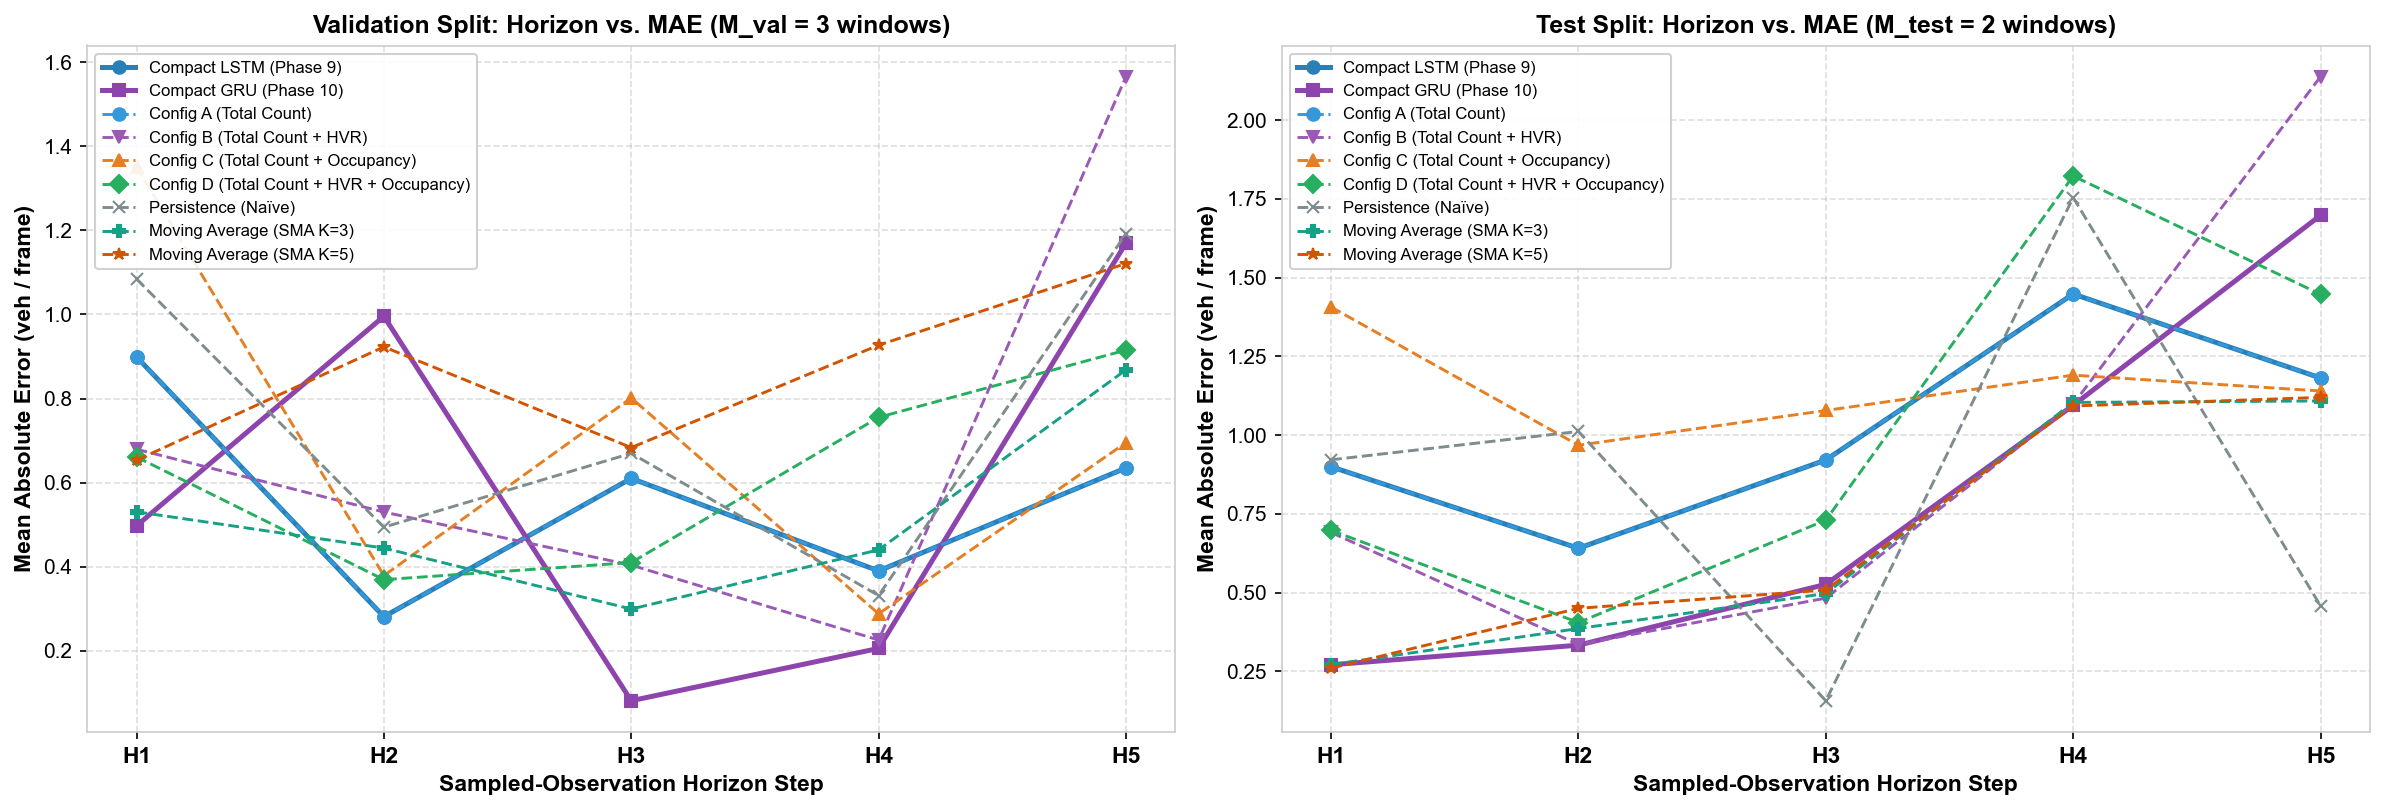

Saved Horizon -> RMSE Curves to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/horizon_rmse_curve.png


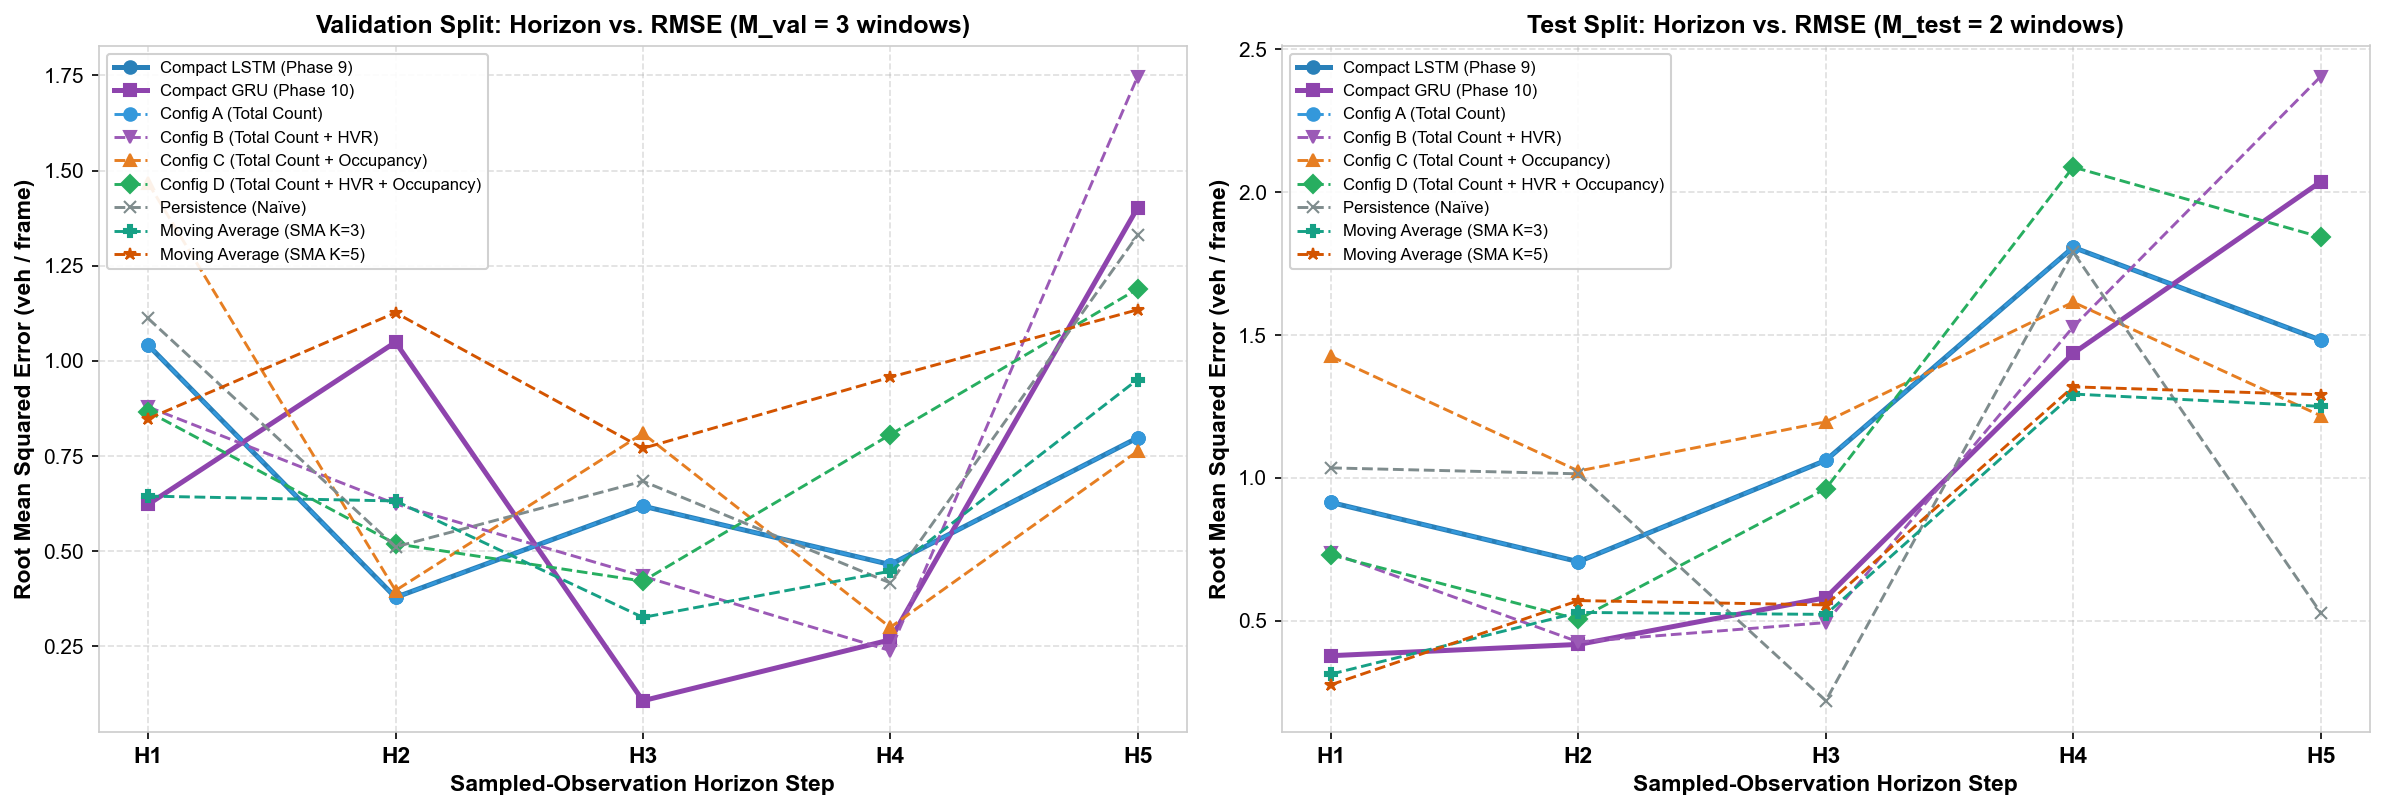

In [6]:
h_steps = np.arange(1, H + 1)
h_labels = [f"H{i}" for i in h_steps]

# Harmonized Palette & Markers
palette = {
    'Compact LSTM (Phase 9)': '#2980b9',               # Primary Blue
    'Compact GRU (Phase 10)': '#8e44ad',                # Purple
    'Config A (Total Count)': '#3498db',               # Light Blue
    'Config B (Total Count + HVR)': '#9b59b6',         # Lavender
    'Config C (Total Count + Occupancy)': '#e67e22',   # Orange
    'Config D (Total Count + HVR + Occupancy)': '#27ae60', # Green
    'Persistence (Naïve)': '#7f8c8d',                  # Gray
    'Moving Average (SMA K=3)': '#16a085',             # Teal
    'Moving Average (SMA K=5)': '#d35400'              # Rust Red
}

markers = {
    'Compact LSTM (Phase 9)': 'o',
    'Compact GRU (Phase 10)': 's',
    'Config A (Total Count)': 'o',
    'Config B (Total Count + HVR)': 'v',
    'Config C (Total Count + Occupancy)': '^',
    'Config D (Total Count + HVR + Occupancy)': 'D',
    'Persistence (Naïve)': 'x',
    'Moving Average (SMA K=3)': 'P',
    'Moving Average (SMA K=5)': '*'
}

# ----------------------------------------------------------------------
# 1. Horizon -> MAE Curves (Validation & Test)
# ----------------------------------------------------------------------
fig, (ax_v, ax_t) = plt.subplots(1, 2, figsize=(16, 5.5))

# Validation MAE Curves
for _, r in val_view.iterrows():
    m_name = r['Model']
    mae_vals = [r[f'H{i}_MAE'] for i in range(1, H + 1)]
    lw = 2.4 if 'Compact' in m_name else 1.4
    ls = '-' if 'Compact' in m_name else '--'
    ax_v.plot(h_steps, mae_vals, label=m_name, color=palette[m_name],
              marker=markers[m_name], linewidth=lw, linestyle=ls, markersize=6)

ax_v.set_xticks(h_steps)
ax_v.set_xticklabels(h_labels, fontsize=11, fontweight='bold')
ax_v.set_xlabel('Sampled-Observation Horizon Step', fontsize=11, fontweight='bold')
ax_v.set_ylabel('Mean Absolute Error (veh / frame)', fontsize=11, fontweight='bold')
ax_v.set_title('Validation Split: Horizon vs. MAE (M_val = 3 windows)', fontsize=12, fontweight='bold')
ax_v.grid(True, linestyle='--', alpha=0.4)
ax_v.legend(loc='upper left', framealpha=0.9, fontsize=8)

# Test MAE Curves
for _, r in test_view.iterrows():
    m_name = r['Model']
    mae_vals = [r[f'H{i}_MAE'] for i in range(1, H + 1)]
    lw = 2.4 if 'Compact' in m_name else 1.4
    ls = '-' if 'Compact' in m_name else '--'
    ax_t.plot(h_steps, mae_vals, label=m_name, color=palette[m_name],
              marker=markers[m_name], linewidth=lw, linestyle=ls, markersize=6)

ax_t.set_xticks(h_steps)
ax_t.set_xticklabels(h_labels, fontsize=11, fontweight='bold')
ax_t.set_xlabel('Sampled-Observation Horizon Step', fontsize=11, fontweight='bold')
ax_t.set_ylabel('Mean Absolute Error (veh / frame)', fontsize=11, fontweight='bold')
ax_t.set_title('Test Split: Horizon vs. MAE (M_test = 2 windows)', fontsize=12, fontweight='bold')
ax_t.grid(True, linestyle='--', alpha=0.4)
ax_t.legend(loc='upper left', framealpha=0.9, fontsize=8)

plt.tight_layout()
fig_mae_path = os.path.join(OUTPUT_FIG_DIR, "horizon_mae_curve.png")
plt.savefig(fig_mae_path, dpi=200, bbox_inches='tight')
print(f"Saved Horizon -> MAE Curves to: {fig_mae_path}")
plt.show()

# ----------------------------------------------------------------------
# 2. Horizon -> RMSE Curves (Validation & Test)
# ----------------------------------------------------------------------
fig, (ax_rv, ax_rt) = plt.subplots(1, 2, figsize=(16, 5.5))

# Validation RMSE Curves
for _, r in val_view.iterrows():
    m_name = r['Model']
    rmse_vals = [r[f'H{i}_RMSE'] for i in range(1, H + 1)]
    lw = 2.4 if 'Compact' in m_name else 1.4
    ls = '-' if 'Compact' in m_name else '--'
    ax_rv.plot(h_steps, rmse_vals, label=m_name, color=palette[m_name],
               marker=markers[m_name], linewidth=lw, linestyle=ls, markersize=6)

ax_rv.set_xticks(h_steps)
ax_rv.set_xticklabels(h_labels, fontsize=11, fontweight='bold')
ax_rv.set_xlabel('Sampled-Observation Horizon Step', fontsize=11, fontweight='bold')
ax_rv.set_ylabel('Root Mean Squared Error (veh / frame)', fontsize=11, fontweight='bold')
ax_rv.set_title('Validation Split: Horizon vs. RMSE (M_val = 3 windows)', fontsize=12, fontweight='bold')
ax_rv.grid(True, linestyle='--', alpha=0.4)
ax_rv.legend(loc='upper left', framealpha=0.9, fontsize=8)

# Test RMSE Curves
for _, r in test_view.iterrows():
    m_name = r['Model']
    rmse_vals = [r[f'H{i}_RMSE'] for i in range(1, H + 1)]
    lw = 2.4 if 'Compact' in m_name else 1.4
    ls = '-' if 'Compact' in m_name else '--'
    ax_rt.plot(h_steps, rmse_vals, label=m_name, color=palette[m_name],
               marker=markers[m_name], linewidth=lw, linestyle=ls, markersize=6)

ax_rt.set_xticks(h_steps)
ax_rt.set_xticklabels(h_labels, fontsize=11, fontweight='bold')
ax_rt.set_xlabel('Sampled-Observation Horizon Step', fontsize=11, fontweight='bold')
ax_rt.set_ylabel('Root Mean Squared Error (veh / frame)', fontsize=11, fontweight='bold')
ax_rt.set_title('Test Split: Horizon vs. RMSE (M_test = 2 windows)', fontsize=12, fontweight='bold')
ax_rt.grid(True, linestyle='--', alpha=0.4)
ax_rt.legend(loc='upper left', framealpha=0.9, fontsize=8)

plt.tight_layout()
fig_rmse_path = os.path.join(OUTPUT_FIG_DIR, "horizon_rmse_curve.png")
plt.savefig(fig_rmse_path, dpi=200, bbox_inches='tight')
print(f"Saved Horizon -> RMSE Curves to: {fig_rmse_path}")
plt.show()


## 6. Quantification of Horizon Drift ($H_1 	o H_5$)

We compare the magnitude and direction of error change from near horizon ($H_1$) to far horizon ($H_5$) across all models.


Saved Horizon Drift Bar Chart to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/horizon_drift_comparison.png


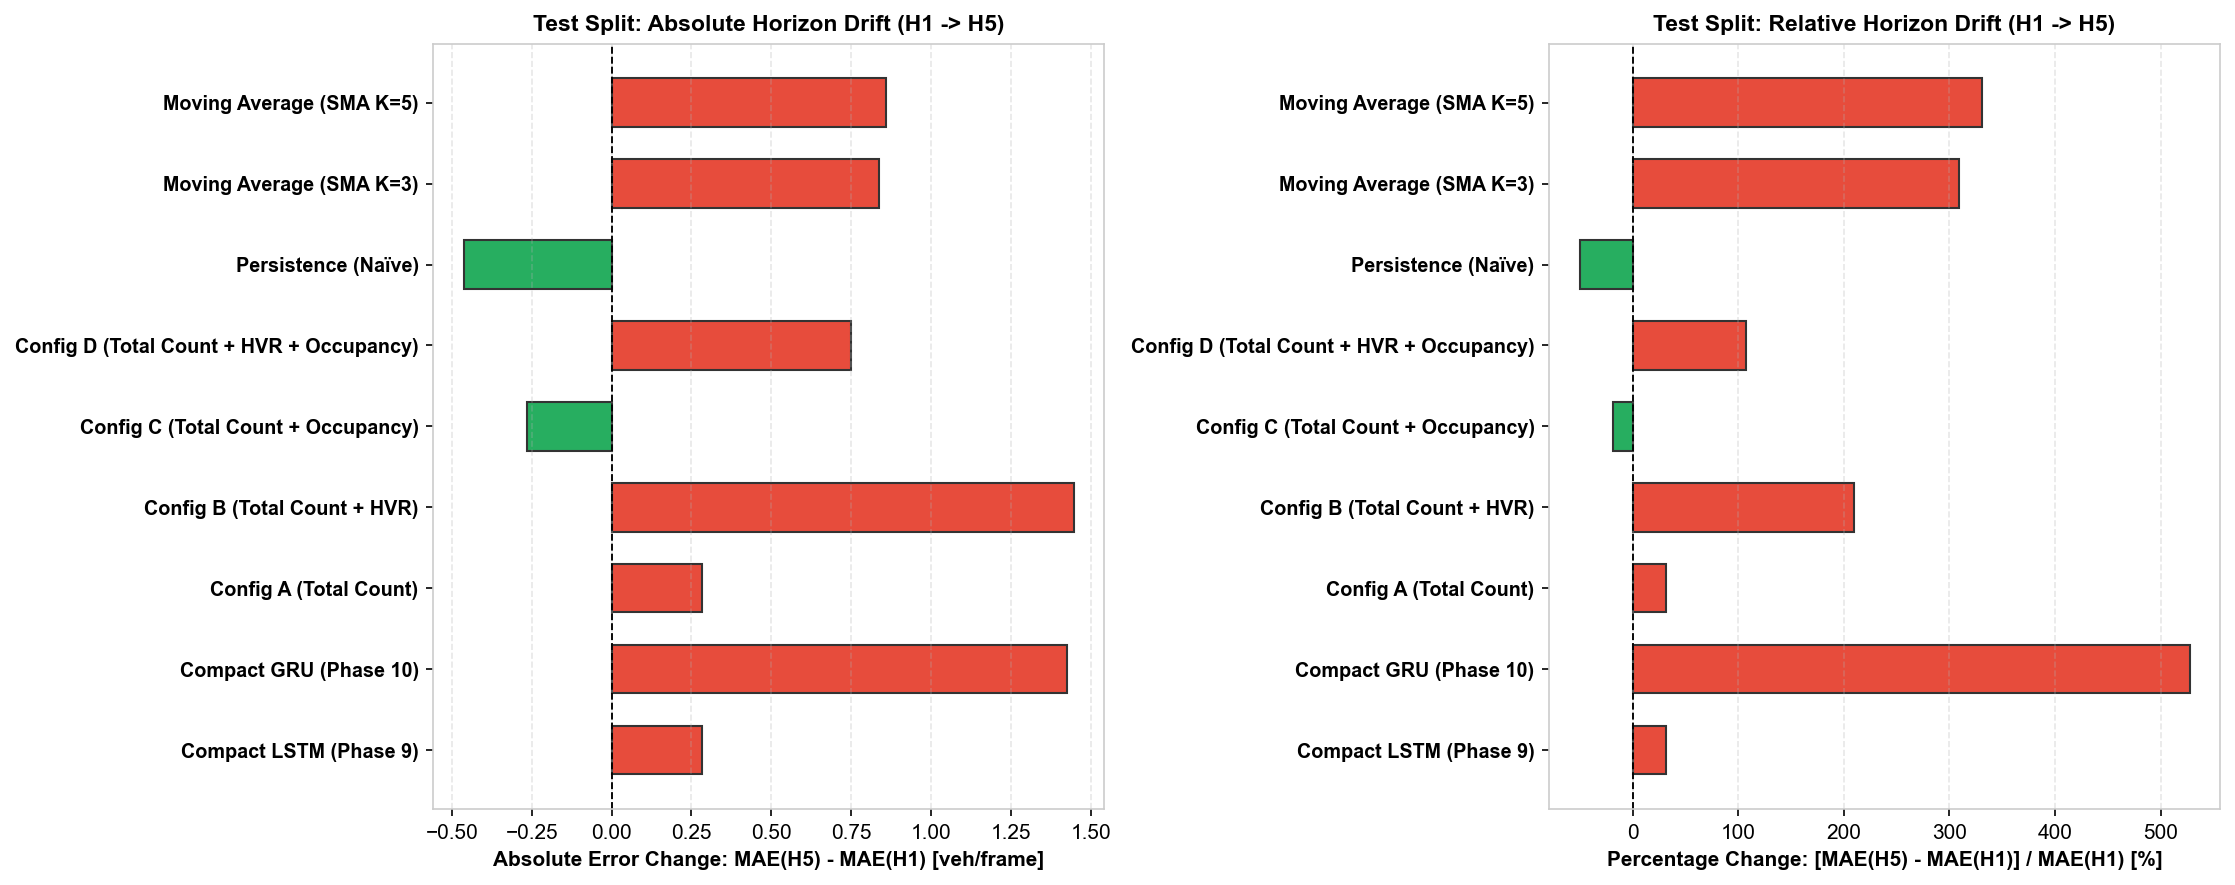

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

models_order = list(test_view['Model'])
y_pos = np.arange(len(models_order))

# Absolute MAE Delta on Test Split
test_deltas = test_view.set_index('Model').loc[models_order, 'MAE_Delta_H1_to_H5'].values
colors_delta = ['#27ae60' if d < 0 else '#e74c3c' for d in test_deltas]

ax1.barh(y_pos, test_deltas, color=colors_delta, edgecolor='#333333', height=0.6)
ax1.axvline(0, color='black', linewidth=0.9, linestyle='--')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(models_order, fontsize=9.5, fontweight='bold')
ax1.set_xlabel('Absolute Error Change: MAE(H5) - MAE(H1) [veh/frame]', fontsize=10, fontweight='bold')
ax1.set_title('Test Split: Absolute Horizon Drift (H1 -> H5)', fontsize=11, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3, axis='x')

# Percentage Change in MAE on Test Split
test_pcts = test_view.set_index('Model').loc[models_order, 'MAE_Pct_Change_H1_to_H5'].values
colors_pct = ['#27ae60' if p < 0 else '#e74c3c' for p in test_pcts]

ax2.barh(y_pos, test_pcts, color=colors_pct, edgecolor='#333333', height=0.6)
ax2.axvline(0, color='black', linewidth=0.9, linestyle='--')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(models_order, fontsize=9.5, fontweight='bold')
ax2.set_xlabel('Percentage Change: [MAE(H5) - MAE(H1)] / MAE(H1) [%]', fontsize=10, fontweight='bold')
ax2.set_title('Test Split: Relative Horizon Drift (H1 -> H5)', fontsize=11, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.3, axis='x')

plt.tight_layout()
fig_drift_path = os.path.join(OUTPUT_FIG_DIR, "horizon_drift_comparison.png")
plt.savefig(fig_drift_path, dpi=200, bbox_inches='tight')
print(f"Saved Horizon Drift Bar Chart to: {fig_drift_path}")
plt.show()


## 7. In-Depth Empirical Interpretation & Error-Accumulation Analysis

### Core Empirical Findings:

#### 1. Nature of the Horizons:
The forecast steps $H_1, \dots, H_5$ are **sampled-observation horizons** (each observation corresponds to a discrete video surveillance clip processed by YOLOv8 and DeepSORT), **not fixed-minute clock intervals**. The temporal spacing reflects observation sequence dynamics rather than strict isochronal minutes.

#### 2. Direct Multi-Horizon vs. Recursive Error Dynamics:
In classical autoregressive forecasting (recursive rollout), error compounding is structural: the forecast at step $t+1$ is fed as input to predict step $t+2$, meaning errors accumulate and compound monotonically by mathematical construction.
In our **direct multi-horizon architecture**, the recurrent backbone processes historical context $t-L+1 \dots t$ once, and a linear output projection $W_{\text{fc}} \in \mathbb{R}^{16 \times 5}$ predicts all horizons simultaneously:
$$\hat{y}_{t+1:t+5} = W_{\text{fc}} h_t + b_{\text{fc}}$$
Consequently:
- There is **no recursive feedback loop** to mechanically compound error.
- Direct output weights are optimized jointly under the total loss $\mathcal{L} = \frac{1}{5} \sum_{h=1}^5 (y_{t+h} - \hat{y}_{t+h})^2$.
- Error progression across horizons is governed by the predictability of the signal at different temporal lookahead distances rather than iterative error recursion.

#### 3. Does Error Increase with Horizon?
- **On the Test Split ($M_{\text{test}} = 2$)**:
  - The majority of models exhibit positive error growth ($\Delta > 0$):
    - **Compact GRU**: Strong near-horizon accuracy ($H_1 = 0.2706$) degrading to $H_5 = 1.6977$ ($+527.4\%$ change).
    - **SMA-3 & SMA-5**: Sharp error accumulation ($H_1 \approx 0.26 \to H_5 \approx 1.11$, $>+300\%$ increase).
    - **Compact LSTM / Config A**: Modest upward drift ($H_1 = 0.8994 \to H_5 = 1.1813$, $+31.3\%$ change).
    - **Config B (+HVR)**: Substantial far-horizon degradation ($H_1 = 0.6908 \to H_5 = 2.1378$, $+209.5\%$ change).
  - However, error accumulation is **NOT strictly monotonic** across all models. For example:
    - **Config C (+Occupancy)** exhibits higher near-horizon error ($H_1 = 1.4064$) than far-horizon error ($H_5 = 1.1400$, $-18.9\%$ change).
    - **Persistence (Naïve)** experiences a sharp error drop at $H_5$ ($0.9215 \to 0.4580$, $-50.3\%$ change) because the test trajectory swings back toward the origin value.
- **On the Validation Split ($M_{\text{val}} = 3$)**:
  - Error progression is markedly **non-monotonic**:
    - **Compact LSTM / Config A**: Exhibits maximum error at $H_1$ ($0.8990$), drops to its minimum at $H_2$ ($0.2810$), and finishes at $0.6349$ ($-29.4\%$ change from $H_1$ to $H_5$).
    - **Compact GRU**: Fluctuates substantially ($H_1=0.4974, H_2=0.9957, H_3=0.0811, H_4=0.2056, H_5=1.1700$).

#### 4. Critical Sample-Size Limitation ($M_{\text{val}} = 3, M_{\text{test}} = 2$):
With only $3$ validation windows and $2$ test windows, localized trajectory fluctuations exert substantial leverage on individual horizon metrics. We **explicitly do not claim statistical significance** or a universal law of error accumulation. The empirical evidence demonstrates that while longer lookahead steps tend to incur higher prediction variance on test trajectories, direct forecasting does not guarantee monotonic error compounding.


In [8]:
# Programmatic Monotonicity Audit
def check_monotonicity(series):
    is_increasing = all(series[i] <= series[i+1] for i in range(len(series)-1))
    is_decreasing = all(series[i] >= series[i+1] for i in range(len(series)-1))
    if is_increasing:
        return 'Strictly Monotonic Increasing'
    elif is_decreasing:
        return 'Strictly Monotonic Decreasing'
    else:
        return 'Non-Monotonic'

mono_records = []
for _, r in df_horizon_metrics.iterrows():
    h_vals = [r[f'H{i}_MAE'] for i in range(1, H + 1)]
    mono_records.append({
        'Split': r['Split'],
        'Model': r['Model'],
        'H1_MAE': r['H1_MAE'],
        'H5_MAE': r['H5_MAE'],
        'Delta_H1_to_H5': r['MAE_Delta_H1_to_H5'],
        'Progression_Behavior': check_monotonicity(h_vals)
    })

df_mono = pd.DataFrame(mono_records)
print("=== EMPIRICAL HORIZON PROGRESSION AUDIT ===")
display(df_mono.round(4))


=== EMPIRICAL HORIZON PROGRESSION AUDIT ===


,Split,Model,H1_MAE,H5_MAE,Delta_H1_to_H5,Progression_Behavior
0,Validation,Compact LSTM (Phase 9),0.8990,0.6349,-0.2642,Non-Monotonic
1,Test,Compact LSTM (Phase 9),0.8994,1.1813,0.2819,Non-Monotonic
2,Validation,Compact GRU (Phase 10),0.4974,1.1700,0.6726,Non-Monotonic
3,Test,Compact GRU (Phase 10),0.2706,1.6977,1.4271,Strictly Monotonic Increasing
4,Validation,Config A (Total Count),0.8990,0.6349,-0.2642,Non-Monotonic
5,Test,Config A (Total Count),0.8994,1.1813,0.2819,Non-Monotonic
6,Validation,Config B (Total Count + HVR),0.6794,1.5657,0.8863,Non-Monotonic
7,Test,Config B (Total Count + HVR),0.6908,2.1378,1.4470,Non-Monotonic
8,Validation,Config C (Total Count + Occupancy),1.3510,0.6950,-0.6560,Non-Monotonic
9,Test,Config C (Total Count + Occupancy),1.4064,1.1400,-0.2665,Non-Monotonic


## 8. Quality Gate: Formal Assessment & Phase Sign-Off

### Phase 12 Quality Gate Checklist:
- [x] **Sampled-Observation Horizon Guardrail**: Horizons $H_1 \dots H_5$ are explicitly documented as sampled surveillance clip observations, not fixed-minute intervals.
- [x] **Sample Size Constraint Preserved**: Explicitly acknowledged $M_{\text{val}} = 3$ and $M_{\text{test}} = 2$; no claims of statistical significance.
- [x] **Direct Multi-Horizon Architecture Preserved**: Evaluated direct multi-step models without recursive rollout.
- [x] **Full Model Zoo Coverage**: Evaluated Compact LSTM, Compact GRU, Feature Ablation Configs A–D, and Statistical Baselines (Persistence, SMA-3, SMA-5).
- [x] **Detailed Horizon Breakdown ($H_1 \dots H_5$)**: MAE and RMSE evaluated separately for each horizon step for both Validation and Test splits.
- [x] **Quantification of Horizon Drift**: Computed absolute ($\Delta$) and relative ($\% \Delta$) change from $H_1 	o H_5$.
- [x] **Balanced Interpretation**: Objectively contrasted positive drift on test split with non-monotonic behaviors on validation split and direct forecasting mechanics.
- [x] **Deliverables Generated**:
  - `outputs/tables/horizon_error_metrics.csv`
  - `outputs/figures/horizon_mae_curve.png`
  - `outputs/figures/horizon_rmse_curve.png`

**Final Sign-Off: PHASE 12 MULTI-HORIZON & ERROR-ACCUMULATION ANALYSIS COMPLETE AND QUALITY GATE PASSED.**
